In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

COLUMN_MAP = {
    "x1": "limit_bal",
    "x2": "sex",
    "x3": "education",
    "x4": "marriage",
    "x5": "age",
    "x6": "pay_0", 
    "x7": "pay_2", 
    "x8": "pay_3", 
    "x9": "pay_4",
    "x10": "pay_5", 
    "x11": "pay_6",
    "x12": "bill_amt1", 
    "x13": "bill_amt2", 
    "x14": "bill_amt3",
    "x15": "bill_amt4", 
    "x16": "bill_amt5", 
    "x17": "bill_amt6",
    "x18": "pay_amt1", 
    "x19": "pay_amt2", 
    "x20": "pay_amt3",
    "x21": "pay_amt4", 
    "x22": "pay_amt5", 
    "x23": "pay_amt6",
}

raw = fetch_openml(data_id=42477, as_frame=True, parser="auto")
X = raw.data.rename(columns=COLUMN_MAP)
y = raw.target.astype(int)

CLASS_NAMES = ["No Default", "Default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

print("Test samples available:", X_test_scaled.shape[0])



Accuracy: 0.6796666666666666

              precision    recall  f1-score   support

  No Default       0.87      0.70      0.77      4673
     Default       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

Test samples available: 6000


In [7]:
feature_names = X_train_scaled.columns.tolist()

shap_explainer = shap.LinearExplainer(model, X_train_scaled)
shap_exp = shap_explainer(X_test_scaled) 

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=feature_names,
    class_names=CLASS_NAMES,
    mode="classification",
    random_state=42,                                
)

def shap_top(i, k = 5):
    vals = shap_exp.values[i]
    order = np.argsort(np.abs(vals))[::-1][:k]
    return [feature_names[j] for j in order]

def lime_top(i, k = 5):
    exp = lime_explainer.explain_instance(X_test_scaled.iloc[i].values, model.predict_proba, num_features=k)
    pairs = sorted(exp.as_map()[1], key=lambda t: abs(t[1]), reverse=True)[:k]
    return [feature_names[idx] for idx, w in pairs]


sample_idx = [0,1,2,3,4]
for i in sample_idx:
    prediction = CLASS_NAMES[model.predict(X_test_scaled.iloc[[i]])[0]]
    print(f"\nCustomer {i} is predicted to be {prediction}")
    print("SHAP Top-5 Features:", shap_top(i))
    print("LIME Top-5 Features:", lime_top(i))



Background dataset has 24000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=24000 when initializing the masker.



Customer 0 is predicted to be No Default
SHAP Top-5 Features: ['pay_0', 'pay_amt1', 'bill_amt1', 'limit_bal', 'sex']


/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


LIME Top-5 Features: ['pay_0', 'pay_amt1', 'bill_amt1', 'limit_bal', 'pay_3']

Customer 1 is predicted to be No Default
SHAP Top-5 Features: ['pay_0', 'pay_3', 'bill_amt1', 'education', 'pay_amt1']


/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


...

/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


LIME Top-5 Features: ['limit_bal', 'age', 'marriage', 'pay_amt1', 'pay_amt2']

Customer 3 is predicted to be No Default
SHAP Top-5 Features: ['bill_amt1', 'bill_amt2', 'bill_amt5', 'bill_amt4', 'bill_amt6']


/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


LIME Top-5 Features: ['bill_amt1', 'pay_amt1', 'pay_amt2', 'limit_bal', 'bill_amt2']

Customer 4 is predicted to be No Default
SHAP Top-5 Features: ['pay_0', 'limit_bal', 'pay_2', 'bill_amt1', 'pay_3']
LIME Top-5 Features: ['pay_0', 'pay_amt1', 'pay_amt2', 'limit_bal', 'bill_amt1']


/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkaya

 customer                                   SHAP Top-5 Features                                 LIME Top-5 Features  shared  agreement
        0            pay_0, pay_amt1, bill_amt1, limit_bal, sex        pay_0, pay_amt1, bill_amt1, limit_bal, pay_3       4        0.8
        1          pay_0, pay_3, bill_amt1, education, pay_amt1        pay_0, bill_amt1, education, pay_2, marriage       3        0.6
        2               limit_bal, age, sex, pay_amt1, marriage       limit_bal, age, bill_amt5, marriage, pay_amt2       3        0.6
        3 bill_amt1, bill_amt2, bill_amt5, bill_amt4, bill_amt6 bill_amt1, pay_amt1, pay_amt2, limit_bal, education       1        0.2
        4             pay_0, limit_bal, pay_2, bill_amt1, pay_3     pay_0, pay_amt1, pay_amt2, limit_bal, bill_amt1       3        0.6

Average top-5 agreement: 0.56


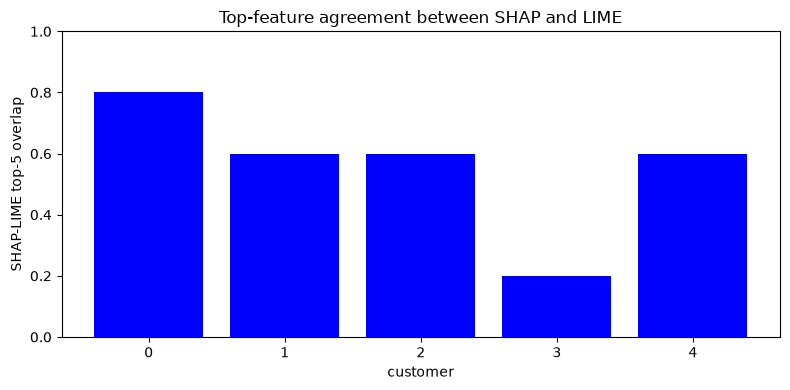

In [8]:
#build one row per customer: SHAP top-5, LIME top-5, and how many they share
rows = []
for i in sample_idx:
    shap = shap_top(i)
    lime = lime_top(i)
    shared = set(shap) & set(lime) #features both methods rank in the top 5
    rows.append({
        "customer": i,
        "SHAP Top-5 Features": ", ".join(shap),
        "LIME Top-5 Features": ", ".join(lime),
        "shared": len(shared),
        "agreement": len(shared) / 5, # 0.0 = no overlap, 1.0 = identical
    })
comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))
print(f"\nAverage top-5 agreement: {comparison['agreement'].mean()}")

plt.figure(figsize=(8, 4))                  
plt.bar(comparison["customer"].astype(str), comparison["agreement"], color="blue") 
plt.ylim(0, 1)                                 
plt.xlabel("customer"); plt.ylabel("SHAP-LIME top-5 overlap")
plt.title("Top-feature agreement between SHAP and LIME")
plt.tight_layout()

/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkaya

 seed                                       LIME_top5
    0    pay_0, pay_amt1, bill_amt1, pay_3, limit_bal
    1 pay_0, pay_amt1, bill_amt1, limit_bal, marriage
    2    pay_0, pay_amt1, bill_amt1, limit_bal, pay_3
    3    pay_0, pay_amt1, bill_amt1, limit_bal, pay_2
    4    pay_0, pay_amt1, bill_amt1, limit_bal, pay_2
    5    pay_0, pay_amt1, bill_amt1, limit_bal, pay_2
    6    pay_0, pay_amt1, bill_amt1, limit_bal, pay_2
    7    pay_0, pay_amt1, bill_amt1, limit_bal, pay_2
    8    pay_0, pay_amt1, bill_amt1, limit_bal, pay_2
    9    pay_0, pay_amt1, bill_amt1, limit_bal, pay_2

Feature appearance rate across seeds (1.0 = always, <1.0 = unstable):
pay_0        1.0
pay_amt1     1.0
bill_amt1    1.0
limit_bal    1.0
pay_2        0.7
pay_3        0.2
marriage     0.1
dtype: float64

SHAP identical across repeats: True


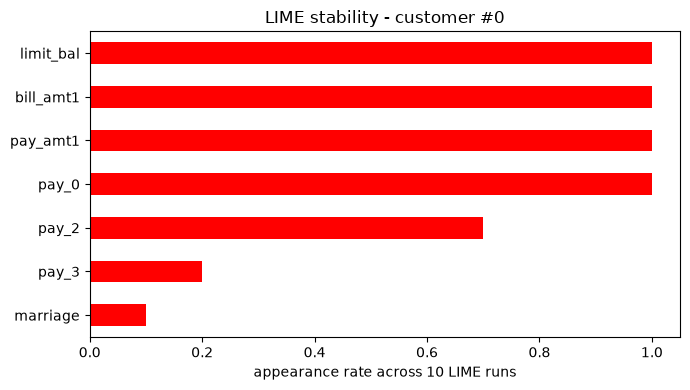

In [9]:
from collections import Counter

# Run LIME for the SAME customer but with a different random seed each time
def lime_top_seeded(i, seed, k=5):
    explainer = LimeTabularExplainer(
        training_data=X_train_scaled.values,
        feature_names=feature_names,
        class_names=CLASS_NAMES,
        mode="classification",
        random_state=seed,
    )
    exp = explainer.explain_instance(X_test_scaled.iloc[i].values, model.predict_proba, num_features=k)
    pairs = sorted(exp.as_map()[1], key=lambda t: abs(t[1]), reverse=True)[:k]
    return [feature_names[idx] for idx, w in pairs]

customer = 0
seeds = range(10)

# Top-5 features for each seed
runs = {s: lime_top_seeded(customer, s) for s in seeds}
stability = pd.DataFrame([{"seed": s, "LIME_top5": ", ".join(f)} for s, f in runs.items()])
print(stability.to_string(index=False))

# How often does each feature show up across the 10 runs? (1.0 = every run)
freq = pd.Series(Counter(f for feats in runs.values() for f in feats)) / len(seeds)
freq = freq.sort_values(ascending=False)
print("\nFeature appearance rate across seeds (1.0 = always, <1.0 = unstable):")
print(freq)

# Contrast: SHAP is deterministic -> identical every time
v1 = shap_explainer(X_test_scaled.iloc[[customer]]).values
v2 = shap_explainer(X_test_scaled.iloc[[customer]]).values
print("\nSHAP identical across repeats:", np.allclose(v1, v2))

# Save table + simple visual
stability.to_csv("outputs/lime_stability_table.csv", index=False)
plt.figure(figsize=(7, 4))
freq.sort_values().plot(kind="barh", color="red")
plt.xlabel("appearance rate across 10 LIME runs")
plt.title(f"LIME stability - customer #{customer}")
plt.tight_layout()
plt.show()



/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkayacan/Desktop/TrustAI/SHAP-LIME_Task1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/beratmertkaya

 customer  SHAP_LIME_agreement  LIME_stability  SHAP_stability
        0                  0.8            0.83             1.0
        1                  0.8            0.83             1.0
        2                  0.8            0.67             1.0
        3                  0.2            0.80             1.0
        4                  0.6            1.00             1.0

Mean LIME stability: 0.83   SHAP stability: 1.00


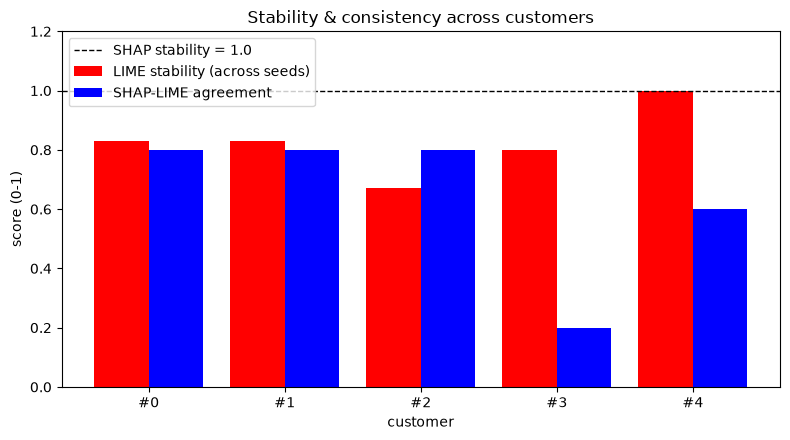

In [ ]:
import numpy as np
from itertools import combinations
from lime.lime_tabular import LimeTabularExplainer

def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) # 1.0 = identical sets, 0 = no overlap

def lime_topk_seeded(i, seed, k=5):
    expl = LimeTabularExplainer(
        training_data=X_train_scaled.values, feature_names=feature_names,
        class_names=CLASS_NAMES, mode="classification", random_state=seed,
    )
    exp = expl.explain_instance(X_test_scaled.iloc[i].values, model.predict_proba, num_features=k)
    pairs = sorted(exp.as_map()[1], key=lambda t: abs(t[1]), reverse=True)[:k]
    return [feature_names[idx] for idx, w in pairs]

customers = [0, 1, 2, 3, 4, 5, 6, 7, 8]
seeds = range(10)

rows = []
for i in customers:
    tops = [lime_topk_seeded(i, s) for s in seeds] # LIME top-5 per seed
    stability = np.mean([jaccard(a, b) for a, b in combinations(tops, 2)]) # self-consistency
    agreement = len(set(shap_top(i)) & set(lime_topk_seeded(i, 42))) / 5 # SHAP vs LIME
    rows.append({
        "customer": i,
        "SHAP_LIME_agreement": round(agreement, 2),
        "LIME_stability": round(stability, 2),
        "SHAP_stability": 1.00, # deterministic reference
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print(f"\nMean LIME stability: {summary['LIME_stability'].mean():.2f}   SHAP stability: 1.00")
summary.to_csv("outputs/stability_summary.csv", index=False)

# Compare LIME self-stability vs SHAP-LIME agreement per customer
x = np.arange(len(summary))
plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, summary["LIME_stability"], width=0.4, label="LIME stability (across seeds)", color="red")
plt.bar(x + 0.2, summary["SHAP_LIME_agreement"], width=0.4, label="SHAP-LIME agreement", color="blue")
plt.axhline(1.0, color="black", lw=1, label="SHAP stability = 1.0")
plt.xticks(x, [f"#{i}" for i in summary["customer"]])
plt.ylim(0, 1.2); plt.xlabel("customer"); plt.ylabel("score (0-1)")
plt.title("Stability & consistency across customers")
plt.legend(); plt.tight_layout()
plt.show()